<a href="https://colab.research.google.com/github/ivanduzunov/AI-Agents-and-Workflows-for-Developers/blob/main/Multi_Agent_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install q langchain langchain-openai

In [3]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
from IPython.display import Image

In [4]:
class SystemState(TypedDict):
    pass

def main(state: SystemState):
  print("Executing node MAIN")

def a(state: SystemState):
  print("Executing node A")

def b1(state: SystemState):
  print("Executing node B1")

def b2(state: SystemState):
  print("Executing node B2")

def finish(state: SystemState):
  print("Executing node FINISH")

In [9]:
checkpointer = InMemorySaver()

In [6]:
sub_graph_builder = StateGraph(SystemState)
sub_graph_builder.add_node("B1", b1)
sub_graph_builder.add_node("B2", b2)

sub_graph_builder.add_edge(START, "B1")
sub_graph_builder.add_edge("B1", "B2")
sub_graph_builder.add_edge("B2", END)

sub_graph = sub_graph_builder.compile()

In [12]:
graph_builder = StateGraph(SystemState)
graph_builder.add_node("main", main)
graph_builder.add_node("A", a)
graph_builder.add_node("B", sub_graph)
graph_builder.add_node("finish", finish)


graph_builder.add_edge(START, "main")
graph_builder.add_edge("main", "A")
graph_builder.add_edge("main", "B")
graph_builder.add_edge("A", "finish")
graph_builder.add_edge("B", "finish")


graph = graph_builder.compile(checkpointer=checkpointer)

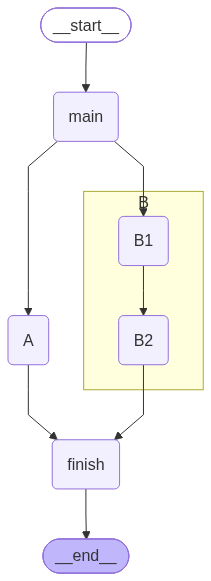

In [14]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png(), format="png"))

In [78]:
thread1_config = {"configurable": {"thread_id": "tr_1"}}
graph.invoke(input={}, config=thread1_config)

Executing node MAIN
Executing node A
Executing node B1
Executing node FINISH
Executing node B2
Executing node FINISH


In [ ]:
list(checkpointer.list(thread1_config))

In [ ]:
list(graph.get_state_history(thread1_config))